In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [2]:
df = ev.build_results_short("results")

In [3]:
df.to_csv("results_1.csv", index=False)

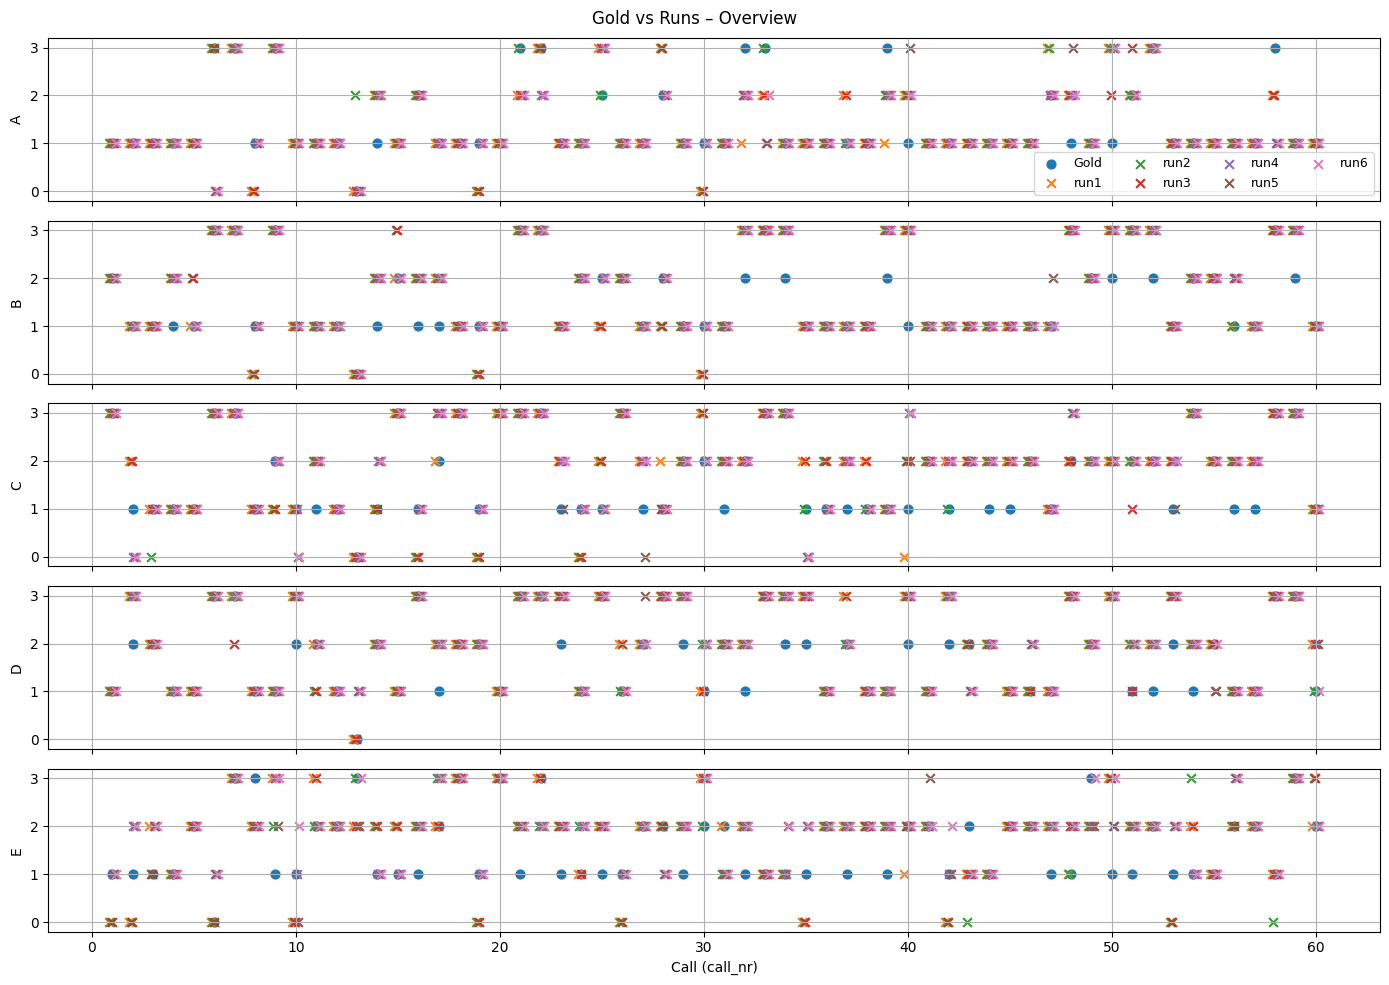

In [4]:
long_df = ev.wide_to_long_runs(df)
ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

In [5]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,error,1,A,60,0.566667,0.0,34,1.402379
1,error,1,B,60,0.333333,0.0,20,0.707107
2,error,1,C,60,0.400000,0.0,24,0.658281
3,error,1,D,60,0.283333,0.0,17,0.532291
4,error,1,E,60,0.716667,1.0,43,1.132843
5,error,2,A,60,0.383333,0.0,23,0.939858
6,error,2,B,60,0.366667,0.0,22,0.730297
7,error,2,C,60,0.366667,0.0,22,0.632456
8,error,2,D,60,0.283333,0.0,17,0.562731
9,error,2,E,60,0.766667,1.0,46,1.224745


In [6]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain
run


In [7]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.566667,0.333333,0.400000,0.283333,0.716667
2,0.383333,0.366667,0.366667,0.283333,0.766667
3,0.433333,0.383333,0.433333,0.350000,0.733333
4,0.666667,0.233333,0.316667,0.366667,0.700000
5,0.733333,0.250000,0.266667,0.383333,0.716667
6,0.616667,0.233333,0.333333,0.316667,0.683333


In [8]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,error,1,300,0.460000,138,6
1,error,2,300,0.433333,130,4
2,error,3,300,0.466667,140,3
3,error,4,300,0.456667,137,9
4,error,5,300,0.470000,141,9
5,error,6,300,0.436667,131,9


In [9]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,138,0
1,2,130,0
2,3,140,0
3,4,137,0
4,5,141,0
5,6,131,0


In [10]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.566667,204,NaN,NaN
1,B,0.300000,108,NaN,NaN
2,C,0.352778,127,NaN,NaN
3,D,0.330556,119,NaN,NaN
4,E,0.719444,259,NaN,NaN


In [11]:
(df == 9).sum()


A            0
A_1          0
A_1_error    0
A_2          0
A_2_error    0
            ..
E_4_error    0
E_5          0
E_5_error    0
E_6          0
E_6_error    0
Length: 65, dtype: int64

In [28]:
import tiktoken

OUTPUT_CONTRACT_DEFAULT = """
Return ONLY valid JSON (no markdown, no commentary).

Schema:
{
  "A": {"severity": <int>},
  "B": {"severity": <int>},
  "C": {"severity": <int>},
  "D": {"severity": <int>},
  "E": {"severity": <int>}
}
""".strip()

prompt = ("You are an expert in analysing emergency calls. \n"
              "You should evaluate the call transcript according the ABCDE schema. \n"
              "ABCDE Schema: Airway, Breathing, Circulation, Disability, Exposure.\n"
              "Give every category a severity score from 0 to 3.\n"
              "**0** – No information available; no conclusions possible\n"  
            "**1** – No or only minor impairment suspected\n"  
            "**2** – Significant impairment present; no acute life threat suspected (ambulance indicated)\n"  
            "**3** – Severe impairment; vital threat possible or likely; immediate intervention required (urgent ambulance, possibly physician response unit)")

text = prompt + "\n\n" + OUTPUT_CONTRACT_DEFAULT


## Token zählen: 


encoding = tiktoken.get_encoding("o200k_base")

tokens = encoding.encode(text)

print("GPT 5.2:" , len(tokens))

GPT 5.2: 187


In [20]:
import anthropic
import pandas as pd
import requests
from dotenv import load_dotenv
from anthropic import Anthropic
import os

load_dotenv()
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
client = anthropic.Anthropic()

response = client.messages.count_tokens(
    model="claude-opus-4-6",
    messages=[{"role": "user", "content": text}],
)

print(response.json())

{"input_tokens":229}


/var/folders/9k/bqn5d5t90kl0x7z66fx4d0cw0000gn/T/ipykernel_20811/1825925790.py:17: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(response.json())
